# Capstone: Define and Solve an ML Problem

In [50]:
import pandas as pd
import numpy as np
import os 
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import tensorflow.keras as keras
from sklearn.preprocessing import StandardScaler
import time

**Note**: As you work through the notebook, you can import additional packages as needed.

## Overview


In this capstone assignment, you will follow the machine learning life cycle and implement one of the supervised learning models you have learned so far in this course, along with a neural network, to solve a predictive problem.

This capstone spans two lab sessions.

- **Unit 5 Lab:** You will define a machine learning problem, explore and prepare your data, and train, test, evaluate and improve a traditional machine learning model (Parts 1–5).
- **Unit 6 Lab:** After completing Unit 6 on neural networks, you will apply a neural network to the same problem and compare the two approaches (Parts 6–7).

There is a checkpoint at the end of Part 5 that marks where to stop during the Unit 5 lab.

You will complete the following:

1. Choose your Data Set and Build Your DataFrame
2. Define Your ML Problem
3. Understand Your Data
4. Prepare Your Data
5. Train, Test, Evaluate and Improve a Traditional Machine Learning Model *(Unit 5 lab)*
6. Train, Test, Evaluate and Improve Neural Network *(Unit 6 lab)*
7. Compare Your Models and Reflect *(Unit 6 lab)*

**This is an individual assignment.** You are welcome to discuss ideas with your peers, but the code and written responses you submit must be your own.

**Note:** This capstone is intentionally less scaffolded than your weekly labs; that is by design. You are expected to make your own implementation choices, add code cells as needed, and document your reasoning throughout.

## Part 1: Choose Your Data Set and Build Your DataFrame


You will choose one of two data sets to work with for this capstone. In both cases, you will be solving a supervised learning binary classification problem by predicting one of two possible class labels. Both data sets have been used earlier in the course, so you are already familiar with their structure. 

**Option A: Census Income Data** (`censusData.csv`)
This data set contains demographic and employment information from the 1994 U.S. Census. You will use it to predict whether an individual's annual income exceeds $50,000. Your label column is `income_binary`, which contains two values: `<=50K` and `>50K`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Option B: Airbnb NYC Listings Data** (`airbnbListingsData.csv`)
This data set contains information about Airbnb listings in New York City. You will use it to predict whether a listing is high-priced. The data set includes a new `price_category` column that classifies each listing as either "high price" or "low price" based on whether the listing’s price falls above or below the 75th percentile of all listing prices. Listings at or above the 75th percentile are labeled as `high`, while the remaining listings are labeled as `low`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Note:**  These versions of the data sets differ slightly from the versions you have worked with in this program. For example, they may not include some of the preprocessing necessary for specific models. 

#### Load a Data Set and Save it as a Pandas DataFrame

The code cell below contains filenames (path + filename) for the two data sets available to you.

<b>Task:</b> In the code cell below, load your chosen data set using `pd.read_csv()` and save it to a DataFrame named `df`. Then call `df.head()` to inspect the first few row of the data set.

In [51]:
# File paths for both data sets
census_filename = os.path.join(os.getcwd(), "data_capstone", "censusData.csv")
airbnb_filename = os.path.join(os.getcwd(), "data_capstone", "airbnbListingsData.csv")

# Load your chosen dataset and save it to df
df = pd.read_csv(census_filename, header=0)

df.head(10)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex_selfID,capital-gain,capital-loss,hours-per-week,native-country,income_binary
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Non-Female,2174,0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Non-Female,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Non-Female,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Non-Female,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K
5,37.0,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40.0,United-States,<=50K
6,49.0,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16.0,Jamaica,<=50K
7,52.0,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Non-Female,0,0,45.0,United-States,>50K
8,31.0,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50.0,United-States,>50K
9,42.0,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Non-Female,5178,0,40.0,United-States,>50K


## Part 2: Define Your ML Problem

The first step of the machine learning life cycle involves defining your business problem. In the markdown cell below, you will clearly define what you are trying to predict and why it matters. 

<b>Task</b>: In the markdown cell below, answer all of the following questions:

1. Which data set did you choose?
2. What is your label? What are you predicting?
3. What features do you plan to use? (This list may change after you explore your data.)
5. Why does this problem matter? Using the business brief you read in the lab overview page, explain how the organization described there could use a model that predicts this label to create value or inform decisions for their client.

1. Census Income Data
2. The label/thing I'm predicting is income_binary
3. Features I plan to use include age, education, marital-status, occupation, capital-gain, and hours-per-week.
4. This problem matters since EquiLend could build and use a predictive model that helps their client CDFI accurately and consistently predict if applicants to their financial programs have an annual income over 50,0000 dollars which helps determine if they qualify for the programs. These programs would provide easy access to loans and financial education to underserved communities across the Midwest.

## Part 3: Understand Your Data

Now that you have defined your problem, perform exploratory data analysis (EDA) with that problem in mind. Consider the following as you inspect your data:

1. What data preparation techniques would you like to use? These data preparation techniques may include:

    * handling missing values
    * finding and replacing outliers
    * performing feature engineering techniques such as one-hot encoding on categorical features
    * selecting appropriate features and removing irrelevant features
    * addressing class imbalance


2. What machine learning model would you like to use that is suitable for your predictive problem and data?
   * You may use one of the following models that you have worked with so far:
        - K-Nearest Neighbors (KNN)
        - Decision Tree
        - Logistic Regression
   * Are there other data preparation techniques that you will need to apply to build a balanced modeling data set for your problem and model? For example, will you need to scale your data?
 

3. How will you evaluate and improve the model's performance?
    * Are there specific evaluation metrics or methods that are appropriate for your problem, dataset, or selected model?
    
<b>Task</b>: In the code cells below, use the techniques you have learned in this course to inspect and analyze your data.

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

### Class Imbalance

Examine the distribution of your label column to determine whether class imbalance is present. Use at least one visualization to show the class distribution. In the **EDA Summary** below, you will discuss how you plan to address any observed imbalance during data preparation.

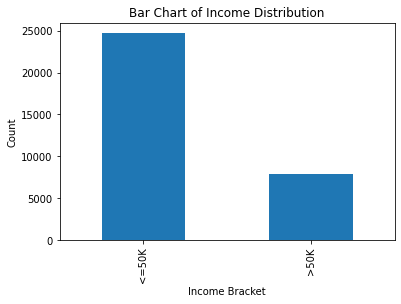

In [52]:
label_count = df['income_binary'].value_counts()

label_count.plot(kind='bar')
plt.title('Bar Chart of Income Distribution')
plt.xlabel('Income Bracket')
plt.ylabel('Count')
plt.show()

### Inspect and Analyze Your Data

Explore your features. Use summary statistics and visualizations to understand how your features are distributed and how they relate to the label. Identify issues such as missing values, outliers, or a feature that is irrelevant or redundant.

Think of the different techniques you have used to inspect and analyze your data in this course. These include using Pandas to apply data filters, using the Pandas `describe()` method to get insight into key statistics for each column, using the Pandas `dtypes` property to inspect the data type of each column, and using Matplotlib and Seaborn to detect outliers and visualize relationships between features and labels. 

Use at least one plot that visualizes a relationship between features and the label.

In [53]:
df.shape

(32561, 15)

In [54]:
feature_cols = df.drop(columns='income_binary')
feature_cols.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32399.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32236.000000
mean,38.589216,1.897784e+05,10.080679,615.907773,87.303830,40.450428
std,13.647862,1.055500e+05,2.572720,2420.191974,402.960219,12.353748
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,14084.000000,4356.000000,99.000000


In [55]:
feature_cols.dtypes

age               float64
workclass          object
fnlwgt              int64
education          object
education-num       int64
marital-status     object
occupation         object
relationship       object
race               object
sex_selfID         object
capital-gain        int64
capital-loss        int64
hours-per-week    float64
native-country     object
dtype: object

In [56]:
df.isnull().sum()

age                162
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex_selfID           0
capital-gain         0
capital-loss         0
hours-per-week     325
native-country     583
income_binary        0
dtype: int64

In [57]:
df['income_binary'] = df['income_binary'].map(
{
    '<=50K': 1,
    '>50K': 0
})

corr_matrix = round(df.corr(), 5)
corr_matrix

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,income_binary
age,1.00000,-0.07627,0.03676,0.12490,0.05755,0.06707,-0.23364
fnlwgt,-0.07627,1.00000,-0.04319,-0.00223,-0.01025,-0.01813,0.00946
education-num,0.03676,-0.04319,1.00000,0.16709,0.07992,0.14726,-0.33515
capital-gain,0.12490,-0.00223,0.16709,1.00000,-0.05514,0.10159,-0.34756
capital-loss,0.05755,-0.01025,0.07992,-0.05514,1.00000,0.05450,-0.15053
hours-per-week,0.06707,-0.01813,0.14726,0.10159,0.05450,1.00000,-0.22952
income_binary,-0.23364,0.00946,-0.33515,-0.34756,-0.15053,-0.22952,1.00000


In [58]:
corrs_sorted = corr_matrix['income_binary'].sort_values(ascending=True)
corrs_sorted

capital-gain     -0.34756
education-num    -0.33515
age              -0.23364
hours-per-week   -0.22952
capital-loss     -0.15053
fnlwgt            0.00946
income_binary     1.00000
Name: income_binary, dtype: float64

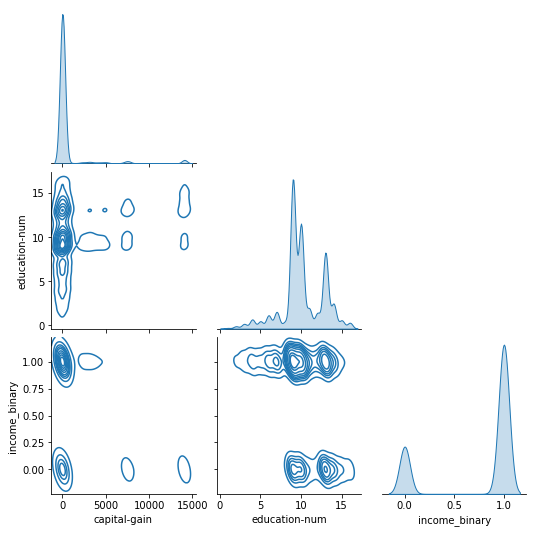

In [59]:
top_two_corr = list(corrs_sorted[0:2].index)

df_corrs = df[top_two_corr].copy()
df_corrs['income_binary'] = df['income_binary']

sns.pairplot(data=df_corrs, kind='kde', corner=True)

### EDA Summary

<b>Task</b>: In the markdown cell below, summarize the key findings from your data exploration. Describe any patterns, anomalies, or data quality issues you identified and explain how those findings may influence your data preparation decisions. For example, your exploration may affect how you handle missing values, address class imbalance, or determine which features to keep or remove.

Class imbalance exists - way more individuals with annual incomes below $50k than above which can greatly skew the model's predictions and weaken its generalizability (harder to predict indivduals that actually don't qualify don't qualify). Need approximately equal samples from both classes.

Some feature columns have null/missing values we need to impute or remove (age, workclass, occupation, hours-per-week, native-country) to build a functionable model.

Need to one-hot encode categorical features to build a functionable model and account for them in predictions.

Based on correlation matrix, numeric feature fnlwgt should be removed since it has a very weak relationship with the label binary_income. Numeric features capital-gain and education-num have a moderate relationship with label, so I considered keeping these features for the model.

### Ethical Considerations:

Machine learning models can cause harm when they reflect or amplify biases in the data they are trained on. 

<b>Task</b>: In the markdown cell below, answer both of the following questions:

1. What biases or ethical concerns might be present in your dataset? Think about who collected the data, how it was collected, and which groups of people appear in it. Are there features in the dataset that could serve as proxies for protected characteristics like race, gender, or socioeconomic status?
2. Who could be harmed by a model that makes incorrect predictions on this data, and how? Be specific about which groups are most at risk and what the real-world consequences of errors might look like.

1. The dataset reflects 1994 labor-market inequities (e.g. gender wage gaps, occupational divide) baked into features like occupation and hours-worked, so the model could learn historical bias incorrectly as a signal. Features in the dataset that could serve as proxies for protected characteristics include native-country, marital-status, education-num, occupation, and relationship.

2. Misclassifications could harm low-income applicants, lending institutions/banks/credit unions/nonprofit financial service organizations (like CDFI), and financial tech companies that supply these models (like EquiLend). If error rates differ by group, applicants who are women, Black/or Hispanic, or immigrants could be disproportionately rejected based on the historical bias from the census data. Thus, the CDFI would be giving financial support to the wrong applicants and EquiLend could be blamed for their faulty model and lose clients/reputation. False negatives would likely be the worst mistake for the model to make since applicants that do need loans/financial support would be rejected from getting exactly what they need.

## Part 4: Prepare Your Data

<b>Task</b>: In the code cell below, prepare your data for modeling. The specific steps you take will depend on what you found during your EDA and which model you plan to use. 

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [60]:
df = df.drop('fnlwgt', axis=1)

In [61]:
df[df['workclass'].isna() & df['occupation'].isna()]['hours-per-week'].describe()

count    1812.000000
mean       31.916115
std        14.905579
min         1.000000
25%        20.000000
50%        36.000000
75%        40.000000
max        99.000000
Name: hours-per-week, dtype: float64

In [62]:
df['workclass'].value_counts()

Private             22696
Self-emp-not-inc     2541
Local-gov            2093
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: workclass, dtype: int64

In [63]:
df['occupation'].value_counts()

Prof-specialty       4140
Craft-repair         4099
Exec-managerial      4066
Adm-clerical         3770
Sales                3650
Other-service        3295
Machine-op-inspct    2002
Transport-moving     1597
Handlers-cleaners    1370
Farming-fishing       994
Tech-support          928
Protective-serv       649
Priv-house-serv       149
Armed-Forces            9
Name: occupation, dtype: int64

In [64]:
df['workclass'] = df['workclass'].fillna('Unknown')

In [65]:
df['occupation'] = df['occupation'].fillna('Unknown')

In [66]:
df['workclass'].value_counts()

Private             22696
Self-emp-not-inc     2541
Local-gov            2093
Unknown              1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: workclass, dtype: int64

In [67]:
df['occupation'].value_counts()

Prof-specialty       4140
Craft-repair         4099
Exec-managerial      4066
Adm-clerical         3770
Sales                3650
Other-service        3295
Machine-op-inspct    2002
Unknown              1843
Transport-moving     1597
Handlers-cleaners    1370
Farming-fishing       994
Tech-support          928
Protective-serv       649
Priv-house-serv       149
Armed-Forces            9
Name: occupation, dtype: int64

In [68]:
df = df.dropna(subset=['age', 'hours-per-week'])

In [69]:
df['native-country'] = df['native-country'].fillna('Unknown')

In [70]:
to_encode = list(df.select_dtypes(include=['object']).columns)
df[to_encode].nunique()

workclass          9
education         16
marital-status     7
occupation        15
relationship       6
race               5
sex_selfID         2
native-country    42
dtype: int64

In [71]:
df['native-country'].value_counts()

United-States                 28735
Mexico                          637
Unknown                         577
Philippines                     194
Germany                         136
Canada                          119
Puerto-Rico                     112
El-Salvador                     104
India                            98
Cuba                             95
England                          86
Jamaica                          80
South                            78
China                            74
Italy                            72
Dominican-Republic               68
Vietnam                          67
Guatemala                        62
Japan                            59
Columbia                         58
Poland                           57
Taiwan                           51
Haiti                            44
Iran                             41
Portugal                         37
Nicaragua                        34
Peru                             31
Greece                      

In [72]:
top_countries = df['native-country'].value_counts().nlargest(8).index
df['native-country'] = df['native-country'].where(df['native-country'].isin(top_countries), 'Other')

df['native-country'].value_counts()

United-States    28735
Other             1461
Mexico             637
Unknown            577
Philippines        194
Germany            136
Canada             119
Puerto-Rico        112
El-Salvador        104
Name: native-country, dtype: int64

In [73]:
encoder = OneHotEncoder(sparse=False)
df_enc = pd.DataFrame(encoder.fit_transform(df[to_encode]))
df_enc.head()

,0,1,2,3,4,5,6,7,8,9,...,59,60,61,62,63,64,65,66,67,68
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [74]:
df_enc.shape

(32075, 69)

In [75]:
#### find numeric columns from df, excluding label
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'income_binary']

#name the encoded columns
df_enc.columns = encoder.get_feature_names(to_encode)

#rest indices so concat allows rows to be lined-up and add label column directly
df_final = pd.concat([
    df[numeric_cols].reset_index(drop=True),
    df_enc.reset_index(drop=True),
    df['income_binary'].reset_index(drop=True)
], axis=1)

In [76]:
feature_list = [col for col in df_final.columns if col != 'income_binary']

### Data Preparation Summary:

<b>Task</b>: In the markdown cell below, document the data preparation steps you took. For each decision, explain why you made it. For example, why did you handle missing values the way you did? Why did you keep or remove certain features? If a preparation step depends on the model you selected (for example, scaling for KNN but not for a decision tree), explain that as well.

- I replaced the workclass and occupation columns na values with 'Unknown' rather than dropping rows to preserve as much data. Rows that had nas for columns age and hours-per-week were dropped since this is numeric data, and a placeholder would most likely distort them. I filled nas in native-country column with 'Unknown'.
- I dropped fnlwgt, since it doesn't describe the specific person in the census like their demographics, so it doesn't belong as a feature. I kept the rest of the features since they are fair indicators of an individual's income-level.
- I one-hot encoded categorical columns since my particular model will be a linear regression model, which expects numeric input. I kept the top 8 most frequent countries in native-country and grouped the rest into 'Other' given one-hot encoding 30+ countries would create a lot of sparse columns, leading the model to memorize noise and coincidental patterns in training over the actual relationship.

## Part 5: Train, Test, Evaluate, and Improve a Traditional Machine Learning Model

Now you will train, test and evaluate your model. You will also use model selection techniques to improve your model's performance by identifying the optimal hyperparameter configuration.

<b>Task</b>: In the code cells below, do the following:

1. Create labeled examples from the dataset
2. Create training and test sets out of the labeled examples 
3. Train, test and evaluate your model 
    * You must evaluate your model using accuracy and F1 score. Use `accuracy_score` and `f1_score` from `sklearn.metrics`. For the F1 score, use `average='binary'` since this is a binary classification problem. You will compare your model's performance to that of a neural network later in this capstone. Save the results of your evaluation metrics to variables for later comparison.
    * You may use additional evaluation metrics of your choosing.
4. Perform model selection through grid search cross-validation to identify optimal hyperparameter values for your model
5. Train, test and evaluate a final version of your model using the optimal hyperparameter configuration.
6. Interpret your model's outputs in the context of the business problem. Depending on the model you chose, this might mean:
    * KNN: Describe what your model's performance metrics tell you about its behavior. For example: How does accuracy change as you vary k? What does that suggest about the structure of your data?
    * Decision Tree: print or plot feature importances.
    * Logistic Regression: print or plot the model coefficients.



<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [77]:
# Create labeled examples from the dataset
y = df_final['income_binary']
X = df_final[feature_list]

In [78]:
# Create training and test sets out of the labeled examples 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20,random_state=1234)

In [79]:
# Train, test and evaluate your model
def train_test_LR(X_train, y_train, X_test, y_test, c=1):
    '''
    Fit a Linear Regression classifier to the training data X_train, y_train.
    Return the loss and accuracy of resulting predictions on the test set.
    Parameters:
    C = Factor that controls how much regularization is applied to the model.
    '''
    # YOUR CODE HERE
    # Solution
    # 1. Create the scikit-learn LogisticRegression model object below and assign to variable 'model'
    model = LogisticRegression(C=c)
    # 2. Fit the model to the training data below
    model.fit(X_train, y_train)
    # 3. Make predictions on the test data using the predict_proba() method and assign the result to the
    # variable 'probability_predictions' below
    probability_predictions = model.predict_proba(X_test)
    # 4. Compute the log loss on 'probability_predictions' and save the result to the variable 'l_loss' below
    l_loss = log_loss(y_test, probability_predictions)
    # 5. Make predictions on the test data using the predict() method and assign the result to the # variable 'class_label_predictions' below
    class_label_predictions = model.predict(X_test)
    # 6. Compute the accuracy score on 'class_label_predictions' and save the result to the variable 'acc_score' below
    acc_score = accuracy_score(y_test, class_label_predictions)
    
    f1 = f1_score(y_test, class_label_predictions, average = 'binary')
    return l_loss, acc_score, f1

In [80]:
loss, acc, f1 = train_test_LR(X_train, y_train, X_test, y_test)
print('Log loss: ' + str(loss))
print('Accuracy: ' + str(acc))
print('F1 score: ' + str(f1))

Log loss: 0.34588396534296495
Accuracy: 0.8428682774746687
F1 score: 0.8996615568385428


/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/_logistic.py:940: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)


In [81]:
# Perform model selection through grid search cross-validation (GridSearchCV)
# to identify optimal hyperparameter values for your model
param_grid = {'C': [.01, 0.1, 1, 10 ,100]}

model = LogisticRegression(max_iter=1000)

grid = GridSearchCV(model, param_grid, cv=5)

grid_search = grid.fit(X_train, y_train)

best_C = grid_search.best_params_['C']

print("Best C:", best_C)

/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/_logistic.py:940: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)
/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/_logistic.py:940: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression


/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/_logistic.py:940: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)
/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/_logistic.py:940: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression


Best C: 100


/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/_logistic.py:940: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)


In [82]:
# Train, test and evaluate a final version of your model using the optimal hyperparameter values.
model_best = LogisticRegression(C = best_C, max_iter=1000)
model_best.fit(X_train, y_train)

proba_predictions = model_best.predict_proba(X_test)
proba_predictions_best = []
for i in proba_predictions:
    proba_predictions_best.append(i[1])

class_label_predictions_best = model_best.predict(X_test)

final_accuracy = accuracy_score(y_test, class_label_predictions_best)
final_f1 = f1_score(y_test, class_label_predictions_best, average='binary')
print('Final Accuracy:', final_accuracy)
print('Final F1 score:', final_f1)

Final Accuracy: 0.8520654715510522
Final F1 score: 0.9050335234664265


/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/_logistic.py:940: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)


In [83]:
c_m = confusion_matrix(y_test, class_label_predictions_best, labels=[1, 0])

pd.DataFrame(
c_m,
columns=['Predicted: <=50K', 'Predicted: >50K'],
index=['Actual: <=50K', 'Actual: >50K']
)

,Predicted: <=50K,Predicted: >50K
Actual: <=50K,4522,351
Actual: >50K,598,944


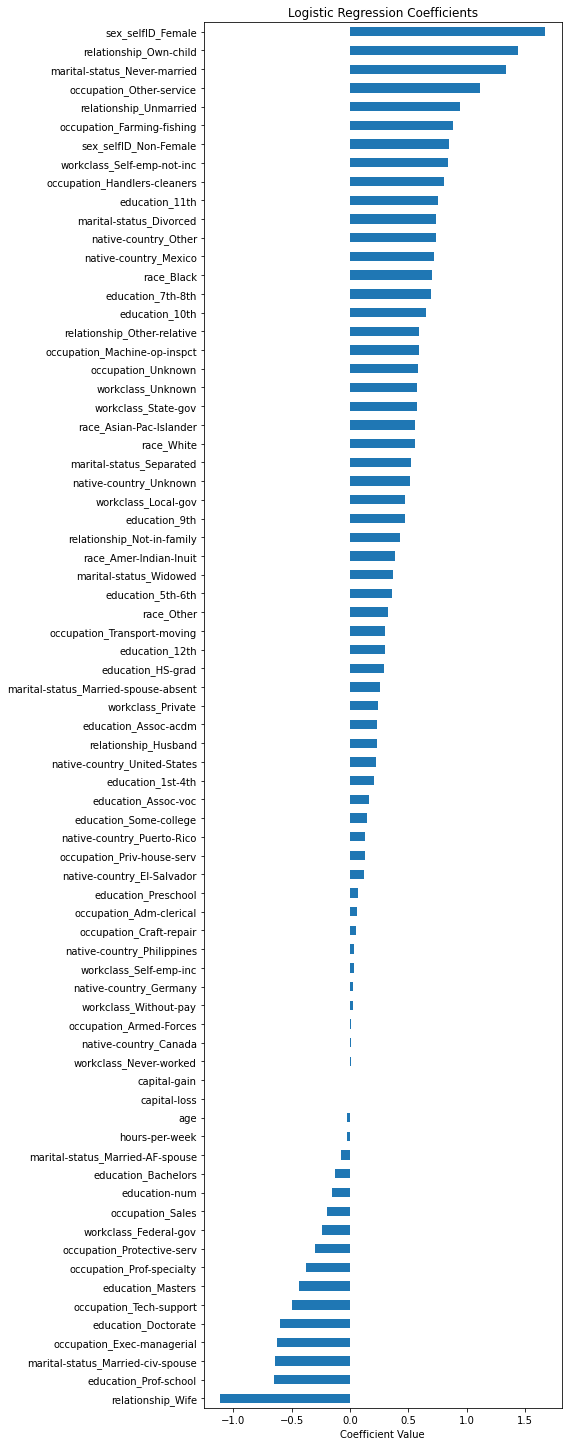

In [84]:
# Interpret your model's outputs 
coefficients = pd.Series(model_best.coef_[0], index=feature_list)
coefficients.sort_values().plot(kind='barh', figsize=(8, 20)) #more vertical room for bars
plt.title('Logistic Regression Coefficients')
plt.tight_layout() #prevents labels from being cut off at the edges
plt.xlabel('Coefficient Value')
plt.show()

### Model Reflection:

<b>Task</b>: In the markdown cell below, answer the following questions:

1. Which model did you choose and why? Reference your problem and data characteristics in your explanation.
2. What did you learn through the model selection process?
3. How do you interpret your model's outputs? What do the predictions or coefficients or feature importances actually mean in the context of your problem?
4. Are there any fairness or ethical concerns with your model? Who might be harmed by incorrect predictions, and are any groups more likely to be affected?

1. I chose the logistic regression model, since the problem requires binary classification (income <= 50k vs >50k) with a mix of categorical and numerical features that are suited for a linear decision boundary. Also the model is interpretable, so CDFI would be able to trace predictions back to specific coefficients that supports transparency when sharing results to applicants.
2. I learned that grid search found C = 100 was optimal meaning weaker regularization performed better than default. Allowing the coefficients more freedom improved fit. I also learned unscaled features caused convergence warnings, but results were still usable.
3. The final model reached approximately 85.2% accuracy and F1 score of 0.905. The confusion matrix showed more missed >50k cases (598) than <=50k cases (351). This means the model is more likely to flag someone as eligible when they don't qualify than to reject an eligible applicant, which is a safer failure for a nonprofit tool. Being female, having a child, or unmarried pushed the predictions toward <=50k while being a wife, having gone to professional school, or being married pushed it toward >50k.
4. Gender was one of the strongest predictors toward <=50k, meaning the model learned historical income disparities in the training data rather than correcting them. The model might systematically make female and unmarried applicants eligible for financial support when some don't actually qualify, taking up spots that "non-traditional" applicants could qualify for (e.g. divorced male applicant with child, white applicant who did'nt graduate high school) which doesn't address CDFI's mission.

---
## ✔️ Unit 5 Checkpoint

**Stop here.** If you have completed Parts 1 through 5, you are done with the Unit 5 portion of this capstone.

Parts 6 and 7 require you to train and evaluate a neural network. You will learn about neural networks in the Unit 6 asynchronous content. Do not start Part 6 until you have completed that material and your lab facilitator has directed you to continue. Do not submit your work for grading until you complete Parts 6 and 7.

Make sure your notebook is saved before you close it.

---
## Part 6: Train, Test, Evaluate and Improve a Neural Network

> **⚠️ Before you write any code in Part 6, do this first.**
> 
> Your notebook does not retain variables between sessions. All of your variables and everything else need to be restored to memory before any code below will work.
> 
> Go to **Kernel > Restart & Run All** to re-run Parts 1 through 5, then scroll back here to continue. If you skip this step, you will see a `NameError` on the first code cell below.

Now you will apply a neural network to the same problem and dataset. You will use Keras to build a feedforward neural network for binary classification.

The scaffolding below will walk you through the steps. Where you see a **Task**, fill in the code. Where you see a **Decision**, you are making an independent choice about your architecture or training process. For each decision, add a comment explaining what you chose and why.


### Prepare Your Data for the Neural Network

Neural networks require all input features to be numeric and scaled. If your features are on very different scales (for example, one feature ranges from 0 to 90 and another from 0 to 99999), the model may train less effectively and have difficulty learning meaningful patterns from the data.

Before training your network, create scaled versions of your training and test data. Use `StandardScaler()` from `sklearn.preprocessing` to standardize your features: 

<b>Task</b>: Complete the code cell below to fit the scaler on your training data, then transform both training and test sets. Save the results to new variables (for example, `X_train_scaled` and `X_test_scaled`) so your original data remains available for reference.

**Note:** Use your scaled data for all neural network steps below.

In [37]:
# Scale your data for the neural network

# Create the scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler to transform the test data
X_test_scaled = scaler.transform(X_test)

### Step 1: Define Your Model Architecture

You will use the Keras `Sequential` class to build your network. Your network should have:

- An input layer with the correct shape for your data
- At least two hidden layers using the `Dense` class
- An output layer appropriate for binary classification

<b>Task:</b> Create a `Sequential` model object and name it `nn_model`. Then construct and add each layer.

**Decision:** How many hidden layers will you use? How many units in each? What activation function will you use for the hidden layers? Add a comment explaining your choices.

In [38]:
# Get the number of features in your training data
n_features = X_train_scaled.shape[1]

# Create the neural network model
nn_model = keras.Sequential()

# Create the input layer and add the input layer to the 'nn_model' object
input_layer = keras.layers.InputLayer(input_shape=(X_train_scaled.shape[1],))
nn_model.add(input_layer)

# Create the hidden layers and add the hidden layers to the 'nn_model' object
# Decision: How many layers? How many units? What activation function?
#3 hidden layers with a half the number of units in subsequent layers (64 -> 32 -> 16 units)
#so each layer compresses the ~70 features into a more condensed representation
#ReLU activation fxn is the standard choice for hidden layers for training efficiency
hidden_layer_1 = keras.layers.Dense(units=64, activation='relu')
nn_model.add(hidden_layer_1)

hidden_layer_2 = keras.layers.Dense(units=32, activation='relu')
nn_model.add(hidden_layer_2)

hidden_layer_3 = keras.layers.Dense(units=16, activation='relu')
nn_model.add(hidden_layer_3)

# Create the output layer and add the output layer to the 'nn_model' object
# Use the correct number of units and activation function for binary classification
#1 unit with sigmoid activation since this is binary classification and sigmoid outputs
#a probability between 0 and 1 for the positive class (<=50k)
output_layer = keras.layers.Dense(units=1, activation='sigmoid')
nn_model.add(output_layer)

# Print a summary of your model
nn_model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 64)                4800      
_________________________________________________________________
dense_1 (Dense)              (None, 32)                2080      
_________________________________________________________________
dense_2 (Dense)              (None, 16)                528       
_________________________________________________________________
dense_3 (Dense)              (None, 1)                 17        
Total params: 7,425
Trainable params: 7,425
Non-trainable params: 0
_________________________________________________________________


### Step 2:  Define the Optimization Function

<b>Task:</b> In the code cell below, create an optimizer object. Use stochastic gradient descent (SGD) with a learning rate of your choosing.

**Decision:** What learning rate will you use? Add a comment explaining your choice.

In [39]:
# Decision: What learning rate will you use? Add a comment explaining your decision.
#I used learning rate of .001 since it balances training time and stability.

sgd_optimizer = keras.optimizers.SGD(learning_rate=0.001)

### Step 3: Define the Loss Function

<b>Task:</b> In the code cell below, create a binary cross entropy loss function using `keras.losses.BinaryCrossentropy()`. Use  the parameter `from_logits=False`. 

In [41]:
loss_fn = keras.losses.BinaryCrossentropy(from_logits=False)

### Step 4: Compile the Model

<b>Task:</b> In the code cell below, package the network architecture with the optimizer and the loss function using the `compile()` method. Use the `accuracy` evaluation metric.

In [42]:
nn_model.compile(optimizer=sgd_optimizer, loss=loss_fn, metrics=['accuracy'])

### Step 5: Fit the Model to the Training Data

We will define our own callback class to output information from our model while it is training. Make sure you execute the code cell below so that it can be used in subsequent cells.

In [43]:
class ProgBarLoggerNEpochs(keras.callbacks.Callback):
    
    def __init__(self, num_epochs: int, every_n: int = 50):
        self.num_epochs = num_epochs
        self.every_n = every_n
    
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n == 0:
            s = 'Epoch [{}/ {}]'.format(epoch + 1, self.num_epochs)
            logs_s = ['{}: {:.4f}'.format(k.capitalize(), v)
                      for k, v in logs.items()]
            s_list = [s] + logs_s
            print(', '.join(s_list))


<b>Task:</b> Use the `fit()` method to fit your model to the training data. Save the result to variable `history.`

Use the `validation_split` parameter to reserve a portion of your training data for validation during training (a common choice is `validation_split=0.2`). After each epoch, the model is evaluated on this validation data, allowing you to monitor how well the model generalizes and helping you detect overfitting.

Also, use the the logger class defined above to track training progress.

**Decision:** How many epochs will you train for? Add a comment explaining your choice.

**Note:** This may take a while to run.

In [44]:
# Decision: How many epochs? Add a comment.
#I selected 100 epochs as a good upper bound and then I will compare the validation loss
#and training loss curves to check for overfitting. This is when the validation loss 
#plateaus or rises before the training loss curve does.

t0 = time.time() # start time

num_epochs = 100 

history = nn_model.fit(
    X_train_scaled, 
    y_train, 
    epochs=num_epochs,
    validation_split=0.2,
    verbose=0,
    callbacks=[ProgBarLoggerNEpochs(num_epochs, every_n=5)],
)
    

t1 = time.time() # stop time

print('Elapsed time: %.2fs' % (t1-t0))

Epoch [5/ 100], Loss: 0.4178, Accuracy: 0.8074, Val_loss: 0.4123, Val_accuracy: 0.8067
Epoch [10/ 100], Loss: 0.3461, Accuracy: 0.8427, Val_loss: 0.3552, Val_accuracy: 0.8346
Epoch [15/ 100], Loss: 0.3306, Accuracy: 0.8470, Val_loss: 0.3425, Val_accuracy: 0.8402
Epoch [20/ 100], Loss: 0.3238, Accuracy: 0.8497, Val_loss: 0.3372, Val_accuracy: 0.8408
Epoch [25/ 100], Loss: 0.3197, Accuracy: 0.8515, Val_loss: 0.3342, Val_accuracy: 0.8441
Epoch [30/ 100], Loss: 0.3168, Accuracy: 0.8524, Val_loss: 0.3322, Val_accuracy: 0.8451
Epoch [35/ 100], Loss: 0.3146, Accuracy: 0.8535, Val_loss: 0.3310, Val_accuracy: 0.8451
Epoch [40/ 100], Loss: 0.3127, Accuracy: 0.8542, Val_loss: 0.3300, Val_accuracy: 0.8457
Epoch [45/ 100], Loss: 0.3112, Accuracy: 0.8549, Val_loss: 0.3294, Val_accuracy: 0.8455
Epoch [50/ 100], Loss: 0.3099, Accuracy: 0.8552, Val_loss: 0.3289, Val_accuracy: 0.8455
Epoch [55/ 100], Loss: 0.3087, Accuracy: 0.8561, Val_loss: 0.3285, Val_accuracy: 0.8459
Epoch [60/ 100], Loss: 0.3076, Ac

### Step 6: Visualize Training Performance

<b>Task:</b>  

Create two plots to visualize the model's performance over time:
1. Training loss and validation loss over epochs, on the same axes.
2. Training accuracy and validation accuracy over epochs, on the same axes.

Label your axes and include a legend.

Use the `history` object returned by `fit()` to obtain this information. 



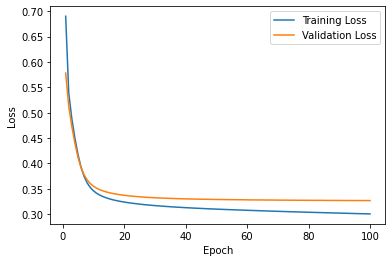

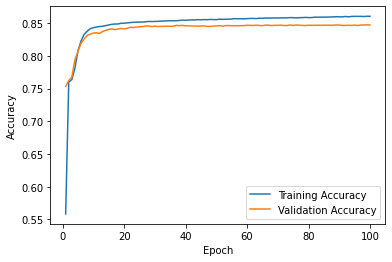

In [45]:
# Plot training loss and validation loss over epochs
plt.plot(range(1, num_epochs + 1), history.history['loss'], label='Training Loss')
plt.plot(range(1, num_epochs + 1), history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot training accuracy and validation accuracy over epochs
plt.plot(range(1, num_epochs + 1), history.history['accuracy'], label='Training Accuracy')
plt.plot(range(1, num_epochs + 1), history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### Step 7: Evaluate the Model's Performance on the Test Set

<b>Task:</b> Use your neural network to generate predictions on the test set and evaluate its performance using accuracy and F1 score. Use `nn_model.predict()` to generate predictions. Since `nn_model.predict()` returns probabilities, apply a threshold of 0.5 to convert probabilities into binary class predictions before computing your metrics. Save your accuracy and F1 score results to clearly named variables so you can compare them to the results from your previous model. Print the results.

In [48]:
# Generate predictions from your neural network using your scaled test data
# nn_model.predict() returns probabilities — apply a threshold of 0.5 to get class labels

nn__probabilities = nn_model.predict(X_test_scaled)
nn_predictions=[]

for i in range(0,len(y_test)):
    if nn__probabilities[i] >= 0.5:
        nn_predictions.append(1)
    else:
        nn_predictions.append(0)

In [49]:
# Compute accuracy and F1 score for the neural network and print the results
nn_accuracy = accuracy_score(y_test, nn_predictions)
nn_f1 = f1_score(y_test, nn_predictions)

print("Neural Network Accuracy:", nn_accuracy)
print("Neural Network F1 Score:", nn_f1)

Neural Network Accuracy: 0.8533125487139517
Neural Network F1 Score: 0.9055694932262919


#### Neural Network Reflection:

<b>Task:</b> In the markdown cell below, answer the following questions:

1. Walk through the architecture decisions you made: number of layers, number of units, activation functions, learning rate, and number of epochs. Why did you make each of those choices?
2. What did your training curves tell you? Did you see any signs of overfitting or underfitting?
3. How did your neural network perform on the test set? Report your accuracy and F1 score here and note whether the result surprised you given what your training curves showed.

1. I decided on three hidden layers (64 -> 32 -> 16 units) in a shrinking pattern to let each layer condense the approximately 70 input features into a more compact representation. ReLU activation was used for these layers since it trains efficiently and avoids some gradient issues. The output layer used 1 unit with the sigmoid activation since this is standard for binary classification. It outputs a probability from 0 to 1. I used the learning rate of 0.001 which balances training speed and stability. Also, I trained for 100 epochs as an upper bound to check if the validation curves show signs of overfitting.
2. Both the loss and accuracy curves for the training and validation datasets stayed close together, with a small and growing gap developing around epoch 20. Training loss kept decreasing while validation loss plateaued and training accuracy slowly kept increasing while validation accuracy plateaued. This suggests signs of mild overfitting, showing the model could have stopped training earlier around epoch 20 without losing performance.
3. The model achieved 85.3% accuracy and an F1 score of 0.906 on the test set. This is not surprising since this is consistent with both what the training and validation accuracy curves were showing (84-86%).

## Part 7: Compare Your Models and Reflect

You have now applied two different approaches to the same problem. In this final section, you will put those results side by side and reflect on what you learned.

###  Results Summary

<b>Task:</b> In the code cell below, create a summary table using a Pandas DataFrame that displays each evaluation metric for both models side by side. Use the variables you created for the accuracy and F1 score metrics. The table should make it easy to compare performance at a glance across every metric you computed.

In [85]:
# Build a side-by-side comparison of your two models using the metric variables
# you created. For example:
#
# results = pd.DataFrame({
#     'Metric': ['Accuracy', 'F1 Score'],
#     'KNN Model': [knn_accuracy, knn_f1],
#     'Neural Network': [nn_accuracy, nn_f1]
# })
# print(results.to_string(index=False))
#
results = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 Score'],
    'Log Regression Model': [final_accuracy, final_f1],
    'Neural Network': [nn_accuracy, nn_f1]
})
print(results.to_string(index=False))

   Metric  Log Regression Model  Neural Network
 Accuracy              0.852065        0.853313
 F1 Score              0.905034        0.905569


### Comparative Analysis

<b>Task:</b> In the markdown cell below, write a comparative analysis that addresses the following. 

1. **Performance comparison.** How did the two models perform relative to each other? Which metrics improved, which stayed the same, and which got worse?

2. **Was the added complexity worth it?** Neural networks are more complex to build, tune, and interpret. Given the performance difference you observed, do you think the neural network justified that added complexity for this problem?

3. **Recommendation.** If you were presenting this work to your company and their client as described in the business brief, which model would you recommend deploying and why? Consider not just performance but also interpretability, training time, and what the costs of different types of errors look like for that specific client.

4. **What you would do next.** If you had more time, what would you try to improve your results? This could include trying different architectures, additional preprocessing steps, different features, or techniques to address class imbalance. Be specific.

1. Both models performed relatively the same. Both the accuracy and f1 score metrics are higher for the neural network model.
2. No, given the added complexity, the accuracy and f1 score were both just slightly higher than the logistic regression model's. It would also be harder to interpret the model design choices (layer count, units, activation functions, learning rate, epochs) than the logistic regression's coefficients.
3. Logistic regression, since both models have nearly the same performance, this model's interpretability is a huge advantage for this scenario. EquiLend's client, CDFL, needs to be able to explain and justify eligibility decisions to applicants and being able to trace a prediction back to specific coefficients supports transparency that neural networks struggle with. The logistic regression model is also faster to train and easier to build and maintain which benefits nonprofits that likely have limited funding and resources.
4. I would address the class imbalance, since the original dataset had more <=50k cases than >50k cases. I would do this by oversampling the minority class, and perhaps I would use a more recent U.S. Census dataset. I would also check if error rates differ across demographic groups such as sex and native-country to get a closer look at fairness concerns.

---
## AI Use Attestation

Reflect honestly on how you used AI tools during this capstone. You are expected to have used AI somewhere in your workflow, and your reflection on that use is what will be evaluated: How clearly you describe your choices, how you verified your work, and what you learned from the process. If you chose not to use AI, explain why. Answer each question in the markdown cell below.

1. Where and at what stages of this capstone did you use AI tools, for example, Claude during brainstorming, coding, or debugging? If you chose not to use AI, explain why.
2. Identify one part of the capstone that required the most effort or thought. What made it challenging, and how did you work through it, with AI or without AI? If you used AI at this point, feel free to share a prompt that worked well or one that did not land the way you expected.
3. How did you verify that your work was correct? What did you look for to catch a mistake, whether it came from AI output or your own reasoning?
4. What is one thing you would do differently next time, either in how you approached the capstone or in how you used AI during it?

1. I used Claude to help me brainstorm how to clean the data in Part 4 for a logistic regression model (e.g. how to deal with features with many categories, how to decide if I should drop a feature) and how to cleanly graph the coefficient values my logistic regression model generated in Part 5. I also used it to debug my code when I was cleaning the dataset.
2. Part 4 required the most effort and thought, since I had to consider countless factors that could hinder model performance and raise more fairness concerns (e.g. class imbalance, features with null/missing values, one-hot encoding, imputing or removing features). One AI prompt that worked well for me was: "How would I one-hot encode the native-country feature? There are over 20+ countries individuals are from." I was suggested to keep the top 10 country names and bucket the less frequent countries to "Other" to minimize losing the other features of individuals.
3. I verified that my work was correct by catching for mistakes myself (e.g. ensuring I chose the correct variables as function arguments, printing and visualizing metrics overtime to check the models aren't overfitting, reviewing confusion matrices) and also asking Claude how to check for overfitting via line graphs for training and validation datasets.
4. I would take more time to do the capstone over the week, so I could understand the machine learning concepts being applied here better and let myself raise more questions.